## Лабораторна робота №1. Навігаційна задача швидкодії

Виконав: Григоренко В. О. КМ-23 Варіант №6

**Вихідні дані (Варіант n = 6):**
* Швидкість судна: $v = \sqrt{6}$
* Параметр течії: $s_0 = \sqrt{6}$
* $f(x_2) = x_2$, $f(x_2) = \sin(x_2)$ 
* $s(x_2) = \sqrt{6} \cdot x_2$, $s(x_2) = \sqrt{6} \cdot \sin(x_2)$
* Відстань до цілі: $l = 6$
* Кут напрямку на ціль: $\phi = \frac{6\pi}{25}$
* Початкові координати: $(0, 0)$

### Завдання 1. Метод диференційних рівнянь з прицілюванням (d1)

Розглянемо корабель (берегової охорони), що рухається зі швидкістю, постійної за величиною відносно води, швидкість течії якої може змінюватися в міру віддалення від берегової лінії. Ми бажаємо визначити програму управління рулями, при якій корабель досягає заданої кінцевої точки з заданого початкового пункту за мінімальний час.

Розв’язуючи цю задачу Коші достатньо довго в часі, визначити, чи можемо ми досягти цілі, чи ні.

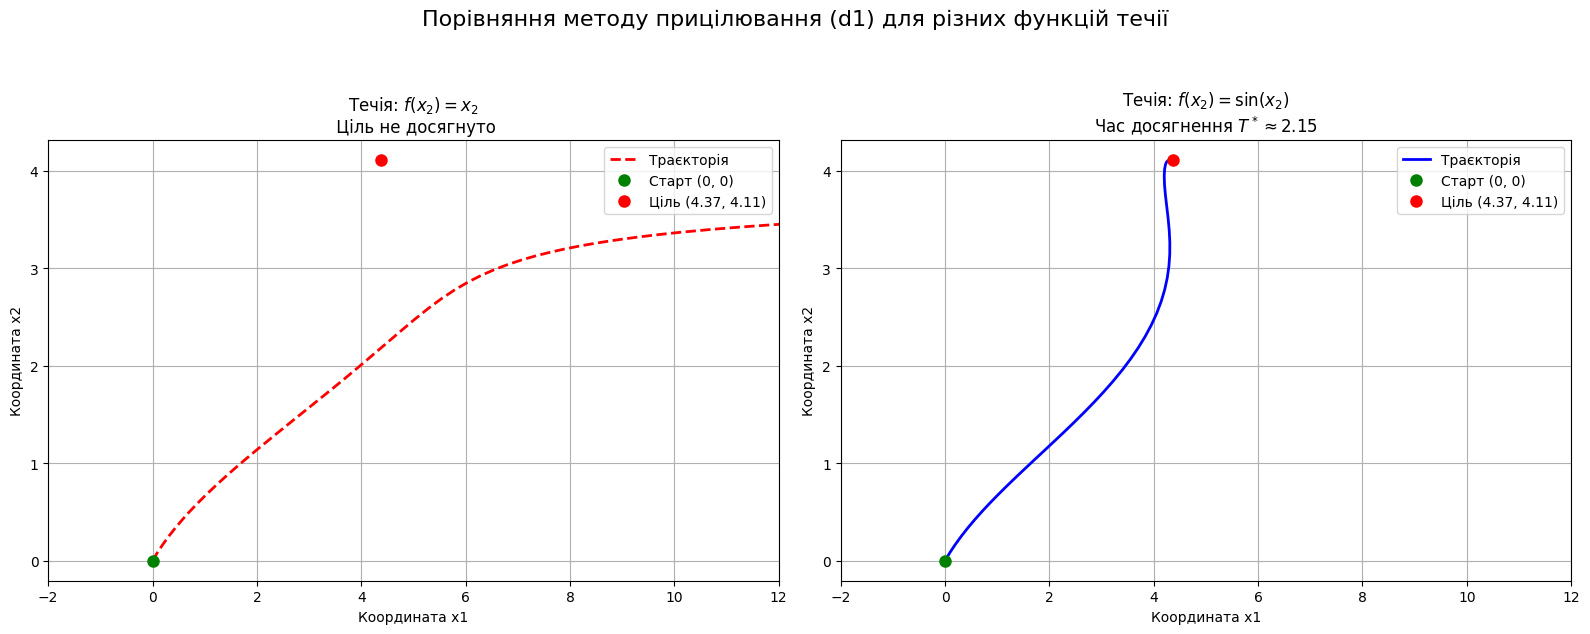

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Вихідні дані (n = 6)
n = 6
v_base = np.sqrt(n)
s0_base = np.sqrt(n)
l = n
fi = n * np.pi / 25

x1_star = l * np.cos(fi)
x2_star = l * np.sin(fi)
target = np.array([x1_star, x2_star])

# Функції течії
def s_linear(x2): return s0_base * x2
def s_sin(x2):    return s0_base * np.sin(x2)

# Системи диференційних рівнянь 
def system_linear(x, t):
    z1, z2 = target[0] - x[0], target[1] - x[1]
    dist = max(np.sqrt(z1**2 + z2**2), 1e-5) 
    return [v_base * (z1 / dist) + s_linear(x[1]), v_base * (z2 / dist)]

def system_sin(x, t):
    z1, z2 = target[0] - x[0], target[1] - x[1]
    dist = max(np.sqrt(z1**2 + z2**2), 1e-5)
    return [v_base * (z1 / dist) + s_sin(x[1]), v_base * (z2 / dist)]

dt = 0.05
max_epochs = 400

traj_linear = [np.array([0.0, 0.0])]
traj_sin = [np.array([0.0, 0.0])]

# 1. Для лінійної течії
curr_pos = np.array([0.0, 0.0])
for _ in range(max_epochs):
    sol = odeint(system_linear, curr_pos, [0, dt])
    curr_pos = sol[-1]
    traj_linear.append(curr_pos)

# 2. Для синусоїдальної течії
curr_pos = np.array([0.0, 0.0])
time_reached = 0.0
for _ in range(max_epochs):
    dist_to_target = np.linalg.norm(target - curr_pos)
    if dist_to_target < 0.1: # окіл точки цілі
        break
    
    sol = odeint(system_sin, curr_pos, [0, dt])
    curr_pos = sol[-1]
    traj_sin.append(curr_pos)
    time_reached += dt

traj_linear = np.array(traj_linear)
traj_sin = np.array(traj_sin)

# Побудова графіків
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Графік лінійного руху течії
ax1.plot(traj_linear[:, 0], traj_linear[:, 1], 'r--', linewidth=2, label='Траєкторія')
ax1.plot(0, 0, 'go', markersize=8, label='Старт (0, 0)')
ax1.plot(target[0], target[1], 'ro', markersize=8, label=f'Ціль ({target[0]:.2f}, {target[1]:.2f})')
ax1.set_title(f'Течія: $f(x_2) = x_2$\n Ціль не досягнуто')
ax1.set_xlabel('Координата x1')
ax1.set_ylabel('Координата x2')
ax1.set_xlim(-2, 12)
ax1.grid(True)
ax1.legend()

# Графік синусоїди
ax2.plot(traj_sin[:, 0], traj_sin[:, 1], 'b-', linewidth=2, label='Траєкторія')
ax2.plot(0, 0, 'go', markersize=8, label='Старт (0, 0)')
ax2.plot(target[0], target[1], 'ro', markersize=8, label=f'Ціль ({target[0]:.2f}, {target[1]:.2f})')
ax2.set_title(f'Течія: $f(x_2) = \\sin(x_2)$\nЧас досягнення $T^* \\approx {time_reached:.2f}$')
ax2.set_xlabel('Координата x1')
ax2.set_ylabel('Координата x2')
ax2.set_xlim(-2, 12)
ax2.grid(True)
ax2.legend()

plt.suptitle('Порівняння методу прицілювання (d1) для різних функцій течії', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Завдання 2. Область досяжності в задачі про човен 

Область досяжності задається (невідомою) функцією $y(x)$, яку треба знайти. Ті точки на площині, які розташовані вище цієї кривій недосяжні як би ми не намагалися вийти за цю криву. Найкращий спосіб вийти в область недосяжності – рухатися перпендикулярно до напрямку дотичної до цієї кривій з максимально можливою швидкістю $v$ човна, але за рахунок течії результуючий вектор руху $V$ буде вздовж цієї кривій.

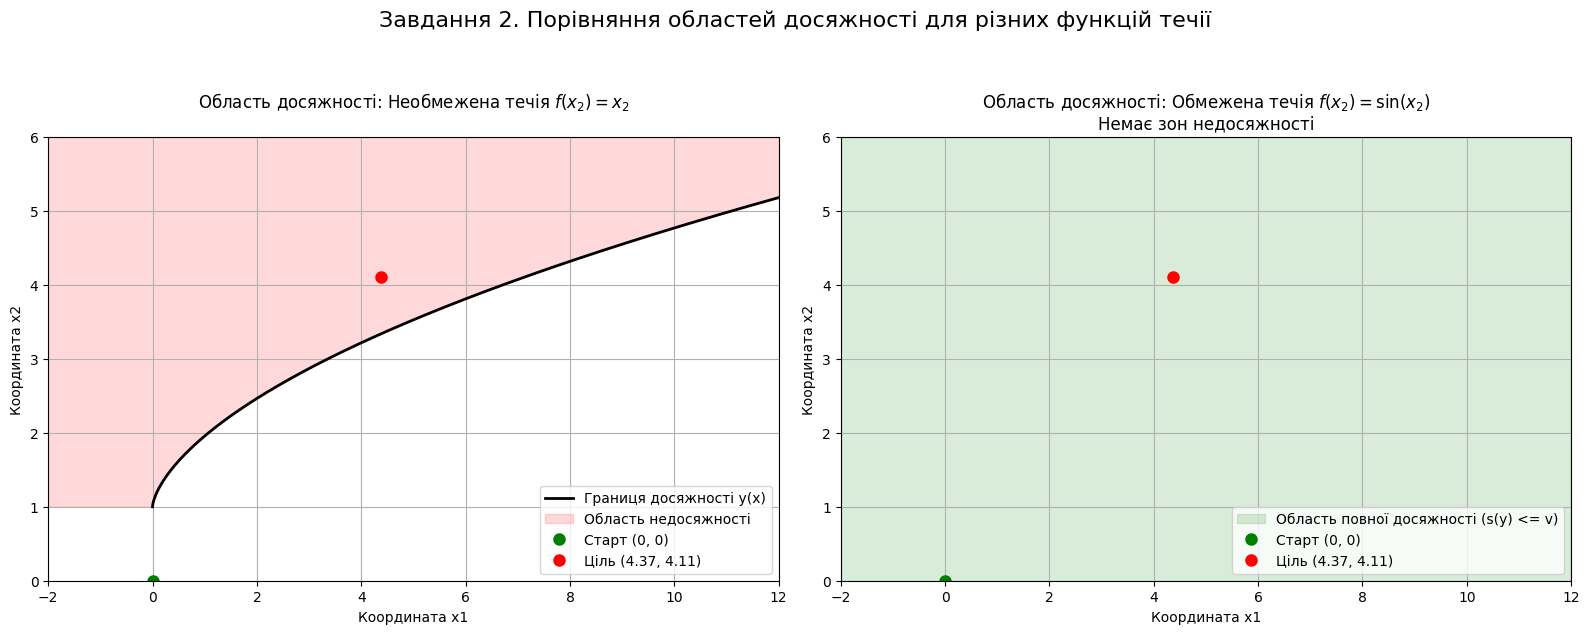

In [16]:
# Рівняння границі досяжності для лінійної течії
def dx_dy_linear(x, y):
    s_y = s0_base * y
    if s_y <= v_base: return 0.0
    return np.sqrt(s_y**2 - v_base**2) / v_base

y_vals = np.linspace(1.0, 6.0, 500)
x_vals_linear = odeint(dx_dy_linear, 0.0, y_vals).flatten()

# Побудова графіків
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Графік лінійної течії
ax1.plot(x_vals_linear, y_vals, 'k-', linewidth=2, label='Границя досяжності y(x)')
ax1.fill_betweenx(y_vals, -5, x_vals_linear, color='red', alpha=0.15, label='Область недосяжності')
ax1.plot(0, 0, 'go', markersize=8, label='Старт (0, 0)')
ax1.plot(target[0], target[1], 'ro', markersize=8, label=f'Ціль ({target[0]:.2f}, {target[1]:.2f})')
ax1.set_title(f'Область досяжності: Необмежена течія $f(x_2) = x_2$\n')
ax1.set_xlabel('Координата x1')
ax1.set_ylabel('Координата x2')
ax1.set_xlim(-2, 12)
ax1.set_ylim(0, 6)
ax1.grid(True)
ax1.legend(loc='lower right')

# Графік синусоїдальної течії
# Оскільки s(x2) <= v завжди, границь немає, вся площина досяжна
ax2.axvspan(-2, 12, color='green', alpha=0.15, label='Область повної досяжності (s(y) <= v)')
ax2.plot(0, 0, 'go', markersize=8, label='Старт (0, 0)')
ax2.plot(target[0], target[1], 'ro', markersize=8, label=f'Ціль ({target[0]:.2f}, {target[1]:.2f})')
ax2.set_title(f'Область досяжності: Обмежена течія $f(x_2) = \sin(x_2)$\nНемає зон недосяжності')
ax2.set_xlabel('Координата x1')
ax2.set_ylabel('Координата x2')
ax2.set_xlim(-2, 12)
ax2.set_ylim(0, 6)
ax2.grid(True)
ax2.legend(loc='lower right')

plt.suptitle('Завдання 2. Порівняння областей досяжності для різних функцій течії', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Метод однокрокового передбачення (d2) 

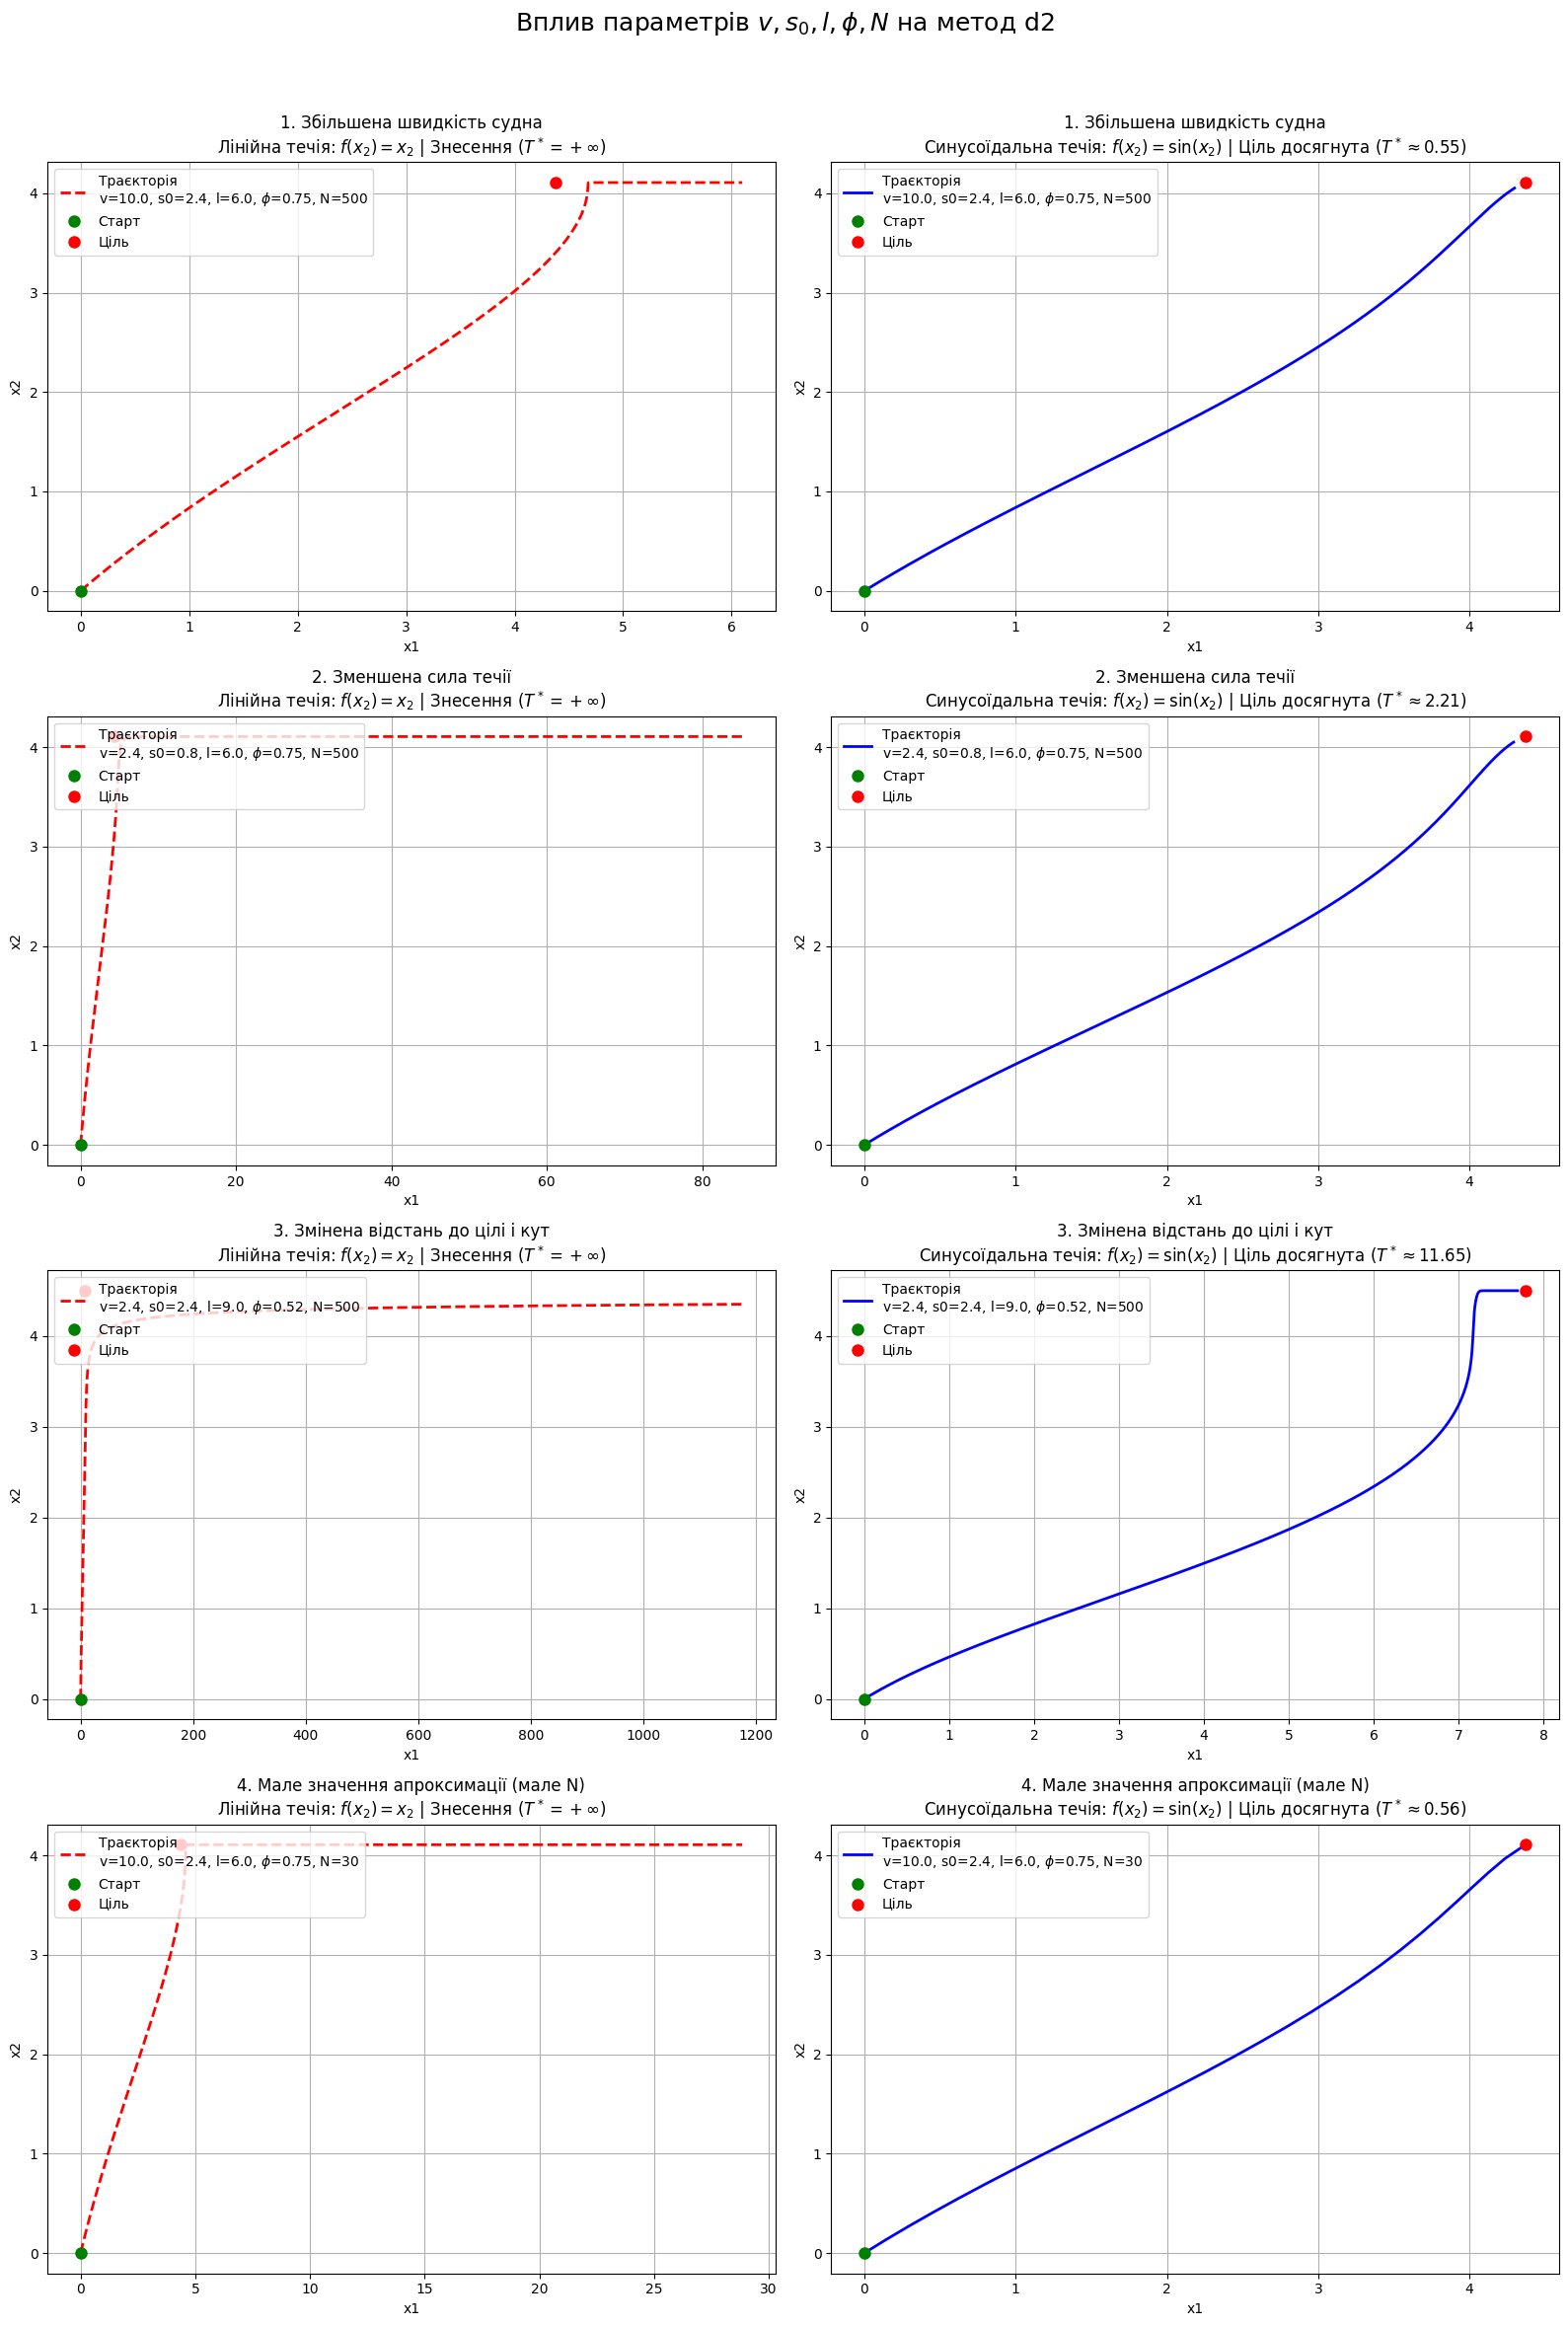

In [20]:
def run_d2_simulation(v, s0, l, fi, N, func_type='linear', max_iters=20000, epsilon=0.1):
    x1_star = l * np.cos(fi)
    x2_star = l * np.sin(fi)
    tau = (l / v) / N
    x1, x2 = 0.0, 0.0
    traj_x1, traj_x2 = [x1], [x2]
    reached = False
    k_total = max_iters
    
    for k in range(max_iters):
        dist = np.sqrt((x1_star - x1)**2 + (x2_star - x2)**2)
        if dist <= epsilon:
            reached = True
            k_total = k
            break
            
        if func_type == 'linear':
            s_curr = s0 * x2
        else:
            s_curr = s0 * np.sin(x2)
            
        term1 = (x1_star - x1 - s_curr * tau)**2
        term2 = (x2_star - x2)**2
        
        lambda_k = np.sqrt(term1 + term2) * v * tau - (v**2) * (tau**2)
        denom = lambda_k + (v**2) * (tau**2)
        
        if denom <= 0:
            k_total = k
            break
            
        u1 = (x1_star - x1 - s_curr * tau) * v * tau / denom
        u2 = (x2_star - x2) * v * tau / denom
        
        norm = np.sqrt(u1**2 + u2**2)
        if norm > 0: 
            u1, u2 = u1 / norm, u2 / norm
            
        x1 = x1 + (s_curr + v * u1) * tau
        x2 = x2 + v * u2 * tau
        traj_x1.append(x1)
        traj_x2.append(x2)
        
    T_star = (l / v) * k_total / N if reached else float('inf')
    return traj_x1, traj_x2, reached, k_total, T_star, x1_star, x2_star

# 4 тестових випадків
cases = [
    {
        "name": "1. Збільшена швидкість судна",
        "params": {"v": 10.0, "s0": s0_base, "l": l, "fi": fi, "N": 500}
    },
    {
        "name": "2. Зменшена сила течії",
        "params": {"v": v_base, "s0": 0.8, "l": l, "fi": fi, "N": 500}
    },
    {
        "name": "3. Змінена відстань до цілі і кут",
        "params": {"v": v_base, "s0": s0_base, "l": 9.0, "fi": np.pi / 6, "N": 500}
    },
    {
        "name": "4. Мале значення апроксимації (мале N)",
        "params": {"v": 10.0, "s0": s0_base, "l": l, "fi": fi, "N": 30} 
    }
]

# Матриця графіків розмірності 4x2
fig, axes = plt.subplots(4, 2, figsize=(16, 24))
fig.suptitle('Вплив параметрів $v, s_0, l, \\phi, N$ на метод d2', fontsize=18, y=0.98)

for i, case in enumerate(cases):
    p = case["params"]
    
    # Для лінійної та синусоїдальної течій
    t_lin_x1, t_lin_x2, r_lin, k_lin, T_lin, x1s, x2s = run_d2_simulation(**p, func_type='linear')
    t_sin_x1, t_sin_x2, r_sin, k_sin, T_sin, _, _ = run_d2_simulation(**p, func_type='sin')
    
    # Текст параметрів для легенди
    param_text = f"v={p['v']:.1f}, s0={p['s0']:.1f}, l={p['l']:.1f}, $\\phi$={p['fi']:.2f}, N={p['N']}"
    
    # Графік зліва: Лінійна течія
    ax1 = axes[i, 0]
    ax1.plot(t_lin_x1, t_lin_x2, 'r--' if not r_lin else 'g-', linewidth=2, label=f'Траєкторія\n{param_text}')
    ax1.plot(0, 0, 'go', markersize=8, label='Старт')
    ax1.plot(x1s, x2s, 'ro', markersize=8, label='Ціль')
    status_lin = f"Ціль досягнута ($T^* \\approx {T_lin:.2f}$)" if r_lin else "Знесення ($T^* = +\\infty$)"
    ax1.set_title(f'{case["name"]}\nЛінійна течія: $f(x_2) = x_2$ | {status_lin}')
    ax1.set_xlabel('x1'); ax1.set_ylabel('x2')
    ax1.grid(True); ax1.legend(loc='upper left')
    
    # Графік справа: Синусоїдальна течія
    ax2 = axes[i, 1]
    ax2.plot(t_sin_x1, t_sin_x2, 'b-', linewidth=2, label=f'Траєкторія\n{param_text}')
    ax2.plot(0, 0, 'go', markersize=8, label='Старт')
    ax2.plot(x1s, x2s, 'ro', markersize=8, label='Ціль')
    status_sin = f"Ціль досягнута ($T^* \\approx {T_sin:.2f}$)" if r_sin else "Знесення ($T^* = +\\infty$)"
    ax2.set_title(f'{case["name"]}\nСинусоїдальна течія: $f(x_2) = \\sin(x_2)$ | {status_sin}')
    ax2.set_xlabel('x1'); ax2.set_ylabel('x2')
    ax2.grid(True); ax2.legend(loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()